<a href="https://colab.research.google.com/github/Sarakazemi-prog/AIHC5020/blob/main/homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
#problem1
import pandas as pd
from google.cloud import storage
import io


In [34]:
from google.colab import auth
auth.authenticate_user()

# Create a GCS client
client = storage.Client()


In [35]:
bucket_name = 'cloud-samples-data'
prefix = 'ml-engine/'
bucket = client.get_bucket(bucket_name)

print(f"Listing blobs in bucket '{bucket_name}' with prefix '{prefix}':")
blobs = client.list_blobs(bucket_name, prefix=prefix)

adult_data_blob_name = None
for blob in blobs:
    if 'adult.data.csv' in blob.name:
        adult_data_blob_name = blob.name
        print(f"Found: {adult_data_blob_name}")
        break

if not adult_data_blob_name:
    raise FileNotFoundError("adult.data.csv not found in the specified GCS location.")


Listing blobs in bucket 'cloud-samples-data' with prefix 'ml-engine/':
Found: ml-engine/census/data/adult.data.csv


In [36]:
def load_csv_blob(blob_name, bucket, column_names=[]):
    """
    Loads a CSV file from a GCS blob into a pandas DataFrame.

    Args:
        blob_name (str): The full path to the CSV file within the bucket.
        bucket (google.cloud.storage.Bucket): The GCS bucket object.
        column_names (list, optional): A list of column names to assign to the DataFrame.
                                      Defaults to [].

    Returns:
        pandas.DataFrame: The DataFrame loaded from the CSV blob.
    """
    blob = bucket.blob(blob_name)
    # Download the blob content as a string
    data_string = blob.download_as_string().decode('utf-8')

    # Use io.StringIO to treat the string as a file-like object for pandas
    if column_names:
        df = pd.read_csv(io.StringIO(data_string), header=None, names=column_names)
    else:
        df = pd.read_csv(io.StringIO(data_string))
    return df


In [37]:
# Column names are not explicitly provided in the problem, but typically adult census data has specific headers.
# I will use common column names for the Adult Census dataset for better readability.
# If no column names are specified, pd.read_csv will infer them (or treat the first row as headers if header=0).
# However, the problem implies that 'adult.data.csv' doesn't have a header row, and we should provide column_names if needed.
# For this dataset, the common approach is to provide column names as it lacks a header.

adult_column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

# Load the adult census data
adult_df = load_csv_blob(adult_data_blob_name, bucket, column_names=adult_column_names)

# Display the first 5 rows
display(adult_df.head())


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [38]:
#problem2

### Problem 2: Querying from BigQuery

First, we need to authenticate and initialize the BigQuery client. Remember to replace `'your-gcp-project-id'` with your actual GCP Project ID.

In [39]:
from google.colab import auth
from google.cloud import bigquery

# Authenticate your Colab environment
auth.authenticate_user()

# ========================================================= #
#               IMPORTANT: USER ACTION REQUIRED             #
#   REPLACE 'your-gcp-project-id' with your ACTUAL GCP Project ID below.
#   You can find your Project ID in the Google Cloud Console.
#   Example: project_id = 'my-unique-gcp-project-12345'
# ========================================================= #
project_id = 'mycourseproject-509914'

# Create a BigQuery client object
client = bigquery.Client(project=project_id)

print(f"BigQuery client initialized for project: {project_id}")


BigQuery client initialized for project: mycourseproject-509914


In [40]:
from google.cloud import bigquery

client = bigquery.Client(project='mycourseproject-509914')

### Write and Execute the SQL Query

Now, let's construct the SQL query to retrieve the daily new confirmed cases and new deaths for Mexico during 2021 from the `bigquery-public-data.covid19_open_data.covid19_open_data` table.

In [41]:
sql_query = """
SELECT
    date,
    new_confirmed,
    new_deceased
FROM
    `bigquery-public-data.covid19_open_data.covid19_open_data`
WHERE
    country_name = 'Mexico' AND
    EXTRACT(YEAR FROM date) = 2021
ORDER BY
    date ASC
"""

# Execute the query and load results into a Pandas DataFrame
covid_df = client.query(sql_query).to_dataframe()

print(f"DataFrame loaded with {len(covid_df)} rows.")


DataFrame loaded with 911770 rows.


### Verify your work

Finally, let's display the first 5 rows of the `covid_df` DataFrame to verify the data.

In [42]:
# Display the first 5 rows
display(covid_df.head())


,date,new_confirmed,new_deceased
0,2021-01-01,<NA>,<NA>
1,2021-01-01,<NA>,<NA>
2,2021-01-01,<NA>,<NA>
3,2021-01-01,<NA>,<NA>
4,2021-01-01,<NA>,<NA>


In [ ]:
#problem3

### Problem 3: Aggregating and Visualizing the Data

First, we'll prepare the data for aggregation by extracting the month from the `date` column and creating a new `month` column.

In [43]:
# Ensure 'date' column is datetime type (it should be from BigQuery query)
covid_df['date'] = pd.to_datetime(covid_df['date'])

# Create a 'month' column from the 'date' column
covid_df['month'] = covid_df['date'].apply(lambda dt: dt.month)

# Display the DataFrame with the new 'month' column
display(covid_df.head())

,date,new_confirmed,new_deceased,month
0,2021-01-01,<NA>,<NA>,1
1,2021-01-01,<NA>,<NA>,1
2,2021-01-01,<NA>,<NA>,1
3,2021-01-01,<NA>,<NA>,1
4,2021-01-01,<NA>,<NA>,1


Now, let's aggregate the data by month, summing up the `new_confirmed` and `new_deceased` cases.

In [44]:
# Aggregate by month
monthly_covid_df = covid_df.groupby('month')[['new_confirmed', 'new_deceased']].sum().reset_index()

# Display the monthly aggregated data
display(monthly_covid_df)

,month,new_confirmed,new_deceased
0,1,424394,39156
1,2,195234,23558
2,3,143254,13099
3,4,93647,7606
4,5,65871,4004
5,6,107135,3152
6,7,381611,8735
7,8,523222,22656
8,9,273774,16481
9,10,124864,8110


Finally, we will visualize the monthly totals for new confirmed cases and new deceased cases using a line plot.

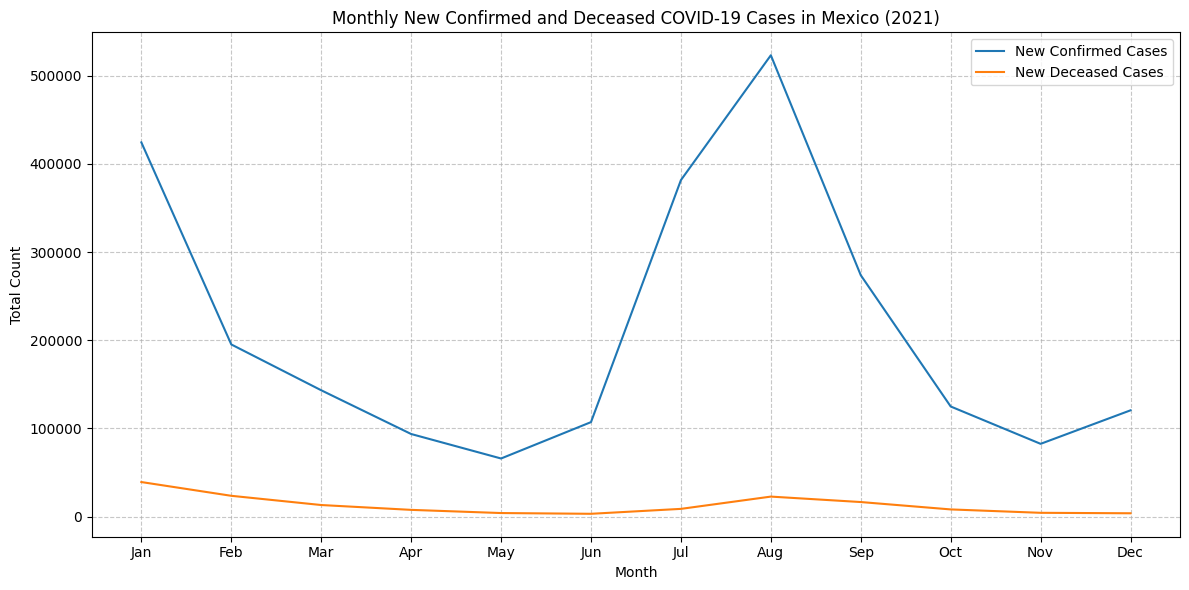

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='new_confirmed', data=monthly_covid_df, label='New Confirmed Cases')
sns.lineplot(x='month', y='new_deceased', data=monthly_covid_df, label='New Deceased Cases')

# Customize the plot
plt.title('Monthly New Confirmed and Deceased COVID-19 Cases in Mexico (2021)')
plt.xlabel('Month')
plt.ylabel('Total Count')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()